In [2]:
import os #Thư viện để thực hiện các thao tác liên quan đến hệ thống tệp.
import cv2 #Thư viện để đọc hình ảnh
import numpy as np # thư viện làm việc với mảng đa chiều
from tqdm import tqdm #thư viện hiển thị thanh tiến trình
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.utils import shuffle # trộn ngẫu nhiên các mảng
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import BatchNormalization
from keras.layers import Input, Lambda, Dense, Flatten, Activation, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import applications

In [18]:
# train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/cleandata/dataset',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training')

validation_generator = train_datagen.flow_from_directory(
   '/kaggle/input/cleandata/dataset',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation')

Found 16689 images belonging to 10 classes.
Found 4167 images belonging to 10 classes.


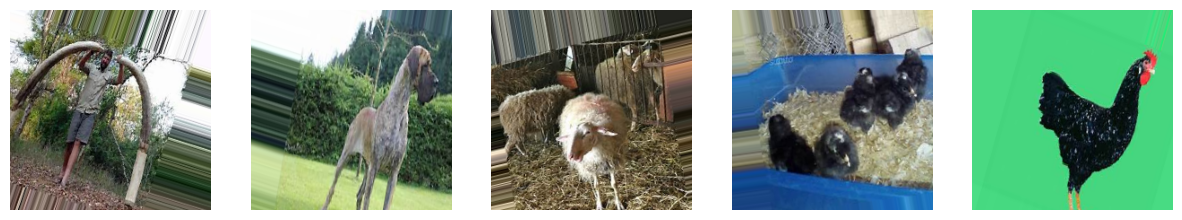

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15,15))

for i in range(5):
    image = next(train_generator)[0][0]
    image = np.squeeze(image)
    ax[i].imshow(image)
    ax[i].axis(False)

In [23]:
# from tensorflow.keras import layers, models
from tensorflow.keras import models, Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
import tensorflow as tf

base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# base_model.trainable = False  # Đóng băng các lớp của ResNet50

model = Sequential()
model.add(base_model) 
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(120, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(10, activation='softmax'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])
model.build((None, 224, 224, 3))
model.summary(expand_nested=True)
# model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_15             │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_pad (ZeroPadding2D)  │ (None, 230, 230, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_conv (Conv2D)        │ (None, 112, 112, 64)   │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_bn                   │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_relu (Activation)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ pool1_pad (ZeroPadding2D)  │ (None, 114, 114, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ pool1_pool (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2_block1_1_conv        │ (None, 56, 56, 64)     │         4,160 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2_block1_1_bn          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2_block1_1_relu        │ (None, 56, 56, 64)     │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2_block1_2_conv        │ (None, 56, 56, 64)     │        36,928 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2_block1_2_bn          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2_block1_2_relu        │ (None, 56, 56, 64)     │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2_block1_0_conv        │ (None, 56, 56, 256)    │        16,640 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2_block1_3_conv        │ (None, 56, 56, 256)    │        16,640 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2_block1_0_bn          │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2_block1_3_bn          │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2_block1_add (Add)     │ (None, 56, 56, 256)    │             

 Total params: 49,313,122 (188.11 MB)

 Trainable params: 49,260,002 (187.91 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils import class_weight
import numpy as np

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

model_checkpoint = ModelCheckpoint('animal_classifier_myteam_epoch_{epoch:02d}.keras', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   save_weights_only=False, 
                                   mode='auto', 
                                   save_freq='epoch')

class_weights_array = class_weight.compute_class_weight(class_weight='balanced',
                                                        classes=np.unique(train_generator.classes),
                                                        y=train_generator.classes)

class_weights = dict(enumerate(class_weights_array))

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    class_weight=class_weights  
)

model.save('animal_classifier_final_myteam.h5')

Epoch 1/20


I0000 00:00:1731936316.078723     185 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_25', 20 bytes spill stores, 20 bytes spill loads



150/261 ━━━━━━━━━━━━━━━━━━━━ 1:30 815ms/step - accuracy: 0.5378 - loss: 1.6589

I0000 00:00:1731936468.988800     188 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_26', 20 bytes spill stores, 20 bytes spill loads



261/261 ━━━━━━━━━━━━━━━━━━━━ 377s 1s/step - accuracy: 0.6280 - loss: 1.4622 - val_accuracy: 0.0802 - val_loss: 2.4889 - learning_rate: 1.0000e-04
Epoch 2/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 264s 991ms/step - accuracy: 0.9131 - loss: 0.8223 - val_accuracy: 0.1665 - val_loss: 2.9455 - learning_rate: 1.0000e-04
Epoch 3/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 265s 992ms/step - accuracy: 0.9405 - loss: 0.7508 - val_accuracy: 0.6691 - val_loss: 1.3461 - learning_rate: 1.0000e-04
Epoch 4/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.9569 - loss: 0.6971 - val_accuracy: 0.9326 - val_loss: 0.7032 - learning_rate: 1.0000e-04
Epoch 5/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 264s 987ms/step - accuracy: 0.9586 - loss: 0.6888 - val_accuracy: 0.9434 - val_loss: 0.6712 - learning_rate: 1.0000e-04
Epoch 6/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 259s 972ms/step - accuracy: 0.9653 - loss: 0.6624 - val_accuracy: 0.9278 - val_loss: 0.7040 - learning_rate: 1.0000e-04
Epoch 7/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 264s 988ms/step -

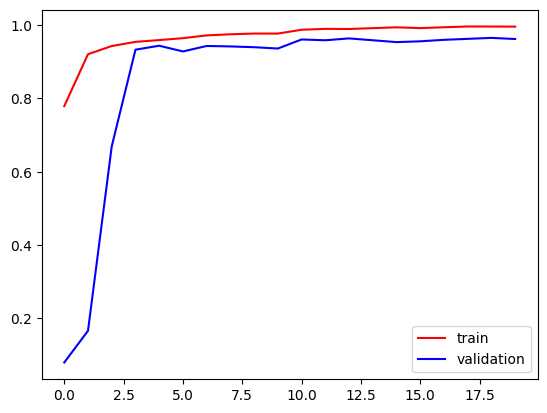

In [25]:
plt.plot(history.history['accuracy'], color= 'red', label ='train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

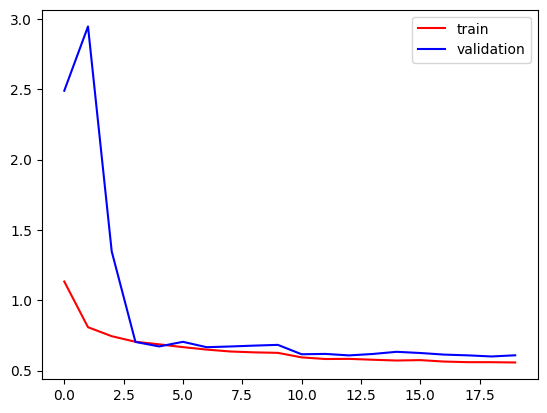

In [26]:
plt.plot(history.history['loss'], color= 'red', label ='train')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

In [33]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras import models

# Tải mô hình đã huấn luyện
my_model = models.load_model('/kaggle/working/animal_classifier_myteam_epoch_19.keras')

# Dự đoán trên tập dữ liệu kiểm tra (validation_generator)
predictions = my_model.predict(validation_generator)

# Chuyển đổi các xác suất thành nhãn lớp dự đoán
predicted_classes = np.argmax(predictions, axis=1)

# Lấy nhãn thật từ validation_generator
true_classes = validation_generator.classes

# Đánh giá độ chính xác (accuracy)
accuracy = accuracy_score(true_classes, predicted_classes)
print(f"Accuracy: {accuracy:.4f}")

# Tạo báo cáo phân loại, bao gồm precision, recall, và f1-score
# `target_names` tương ứng với tên các lớp (class labels)
class_labels = list(validation_generator.class_indices.keys())  # Lấy tên các lớp từ generator
report = classification_report(true_classes, predicted_classes, target_names=class_labels)

# Hiển thị báo cáo phân loại
print("Classification Report:\n", report)

66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 756ms/step
Accuracy: 0.1018
Classification Report:
               precision    recall  f1-score   support

   butterfly       0.07      0.07      0.07       361
         cat       0.10      0.11      0.10       333
     chicken       0.12      0.12      0.12       517
         cow       0.08      0.08      0.08       373
         dog       0.12      0.12      0.12       517
    elephant       0.07      0.07      0.07       289
       horse       0.14      0.14      0.14       524
       sheep       0.09      0.09      0.09       364
      spider       0.10      0.10      0.10       517
    squirrel       0.11      0.11      0.11       372

    accuracy                           0.10      4167
   macro avg       0.10      0.10      0.10      4167
weighted avg       0.10      0.10      0.10      4167



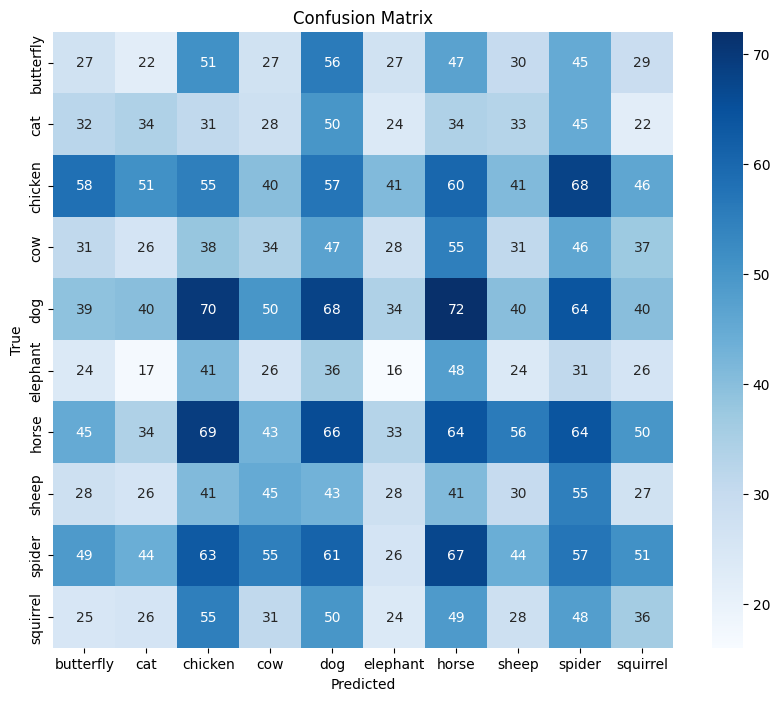

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
my_model = models.load_model('/kaggle/working/animal_classifier_myteam_epoch_19.keras')
conf_matrix = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=validation_generator.class_indices.keys(), yticklabels=validation_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()